In [46]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import re

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

GPU is available
Number of GPUs: 1
GPU Name: NVIDIA GeForce GTX 1080 Ti


In [47]:
! nvidia-smi

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Mon Dec  2 21:47:07 2024       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.90.07              Driver Version: 550.90.07      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1080 Ti     On  |   00000000:02:00.0 Off |                  N/A |
| 48%   71C    P2             95W /  250W |    2379MiB /  11264MiB |     32%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [48]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 300
n_components = 18
n_datapoints = 100000
locs_range = 5
batch_size = 32

In [49]:
import torch
from torch.distributions import constraints
from torch.distributions.utils import broadcast_all
from pyro.distributions import TorchDistribution
from torch import nn

class DiscreteWeibull(TorchDistribution):
    r"""
    Discrete Weibull distribution parameterized by `mu` and `sigma` where:

        - mu = log(a)
        - sigma = 1 / b

    The PMF is defined as:

        P(x) = exp(-exp((ln(x) - mu) / sigma)) - exp(-exp((ln(x+1) - mu) / sigma))

    for x >= 1, and for x = 0:

        P(0) = 1 - exp(-exp((-mu) / sigma))

    Args:
        mu (float or Tensor): location parameter
        sigma (float or Tensor): scale parameter, sigma > 0
    """
    arg_constraints = {'mu': constraints.real, 'sigma': constraints.positive}
    support = constraints.nonnegative_integer
    has_rsample = False

    def __init__(self, mu, sigma, validate_args=None):
        self.mu, self.sigma = broadcast_all(mu, sigma)
        super().__init__(self.mu.size(), validate_args=validate_args)

    def sample(self, sample_shape=torch.Size()):
        shape = sample_shape + self.mu.size()
        U = torch.rand(shape, device=self.mu.device, dtype=self.mu.dtype)
        E = -torch.log(U)
        x = torch.exp(self.mu) * E ** self.sigma - 1
        samples = torch.floor(x).clamp(min=0).long()
        return samples

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)
        x = value.type_as(self.mu)

        is_zero = (x == 0)
        # For x >= 1
        z1 = (torch.log(x + 1e-10) - self.mu) / self.sigma  # Add epsilon to avoid log(0)
        z2 = (torch.log(x + 1) - self.mu) / self.sigma

        s1 = -torch.exp(z1)
        s2 = -torch.exp(z2)

        # Compute log_pmf
        # For x = 0
        log_pmf_zero = torch.log1p(-torch.exp(s2))

        # For x >= 1
        log_pmf_positive = s1 + torch.log1p(-torch.exp(s2 - s1))

        log_pmf = torch.where(is_zero, log_pmf_zero, log_pmf_positive)
        return log_pmf

    def cdf(self, value):
        if self._validate_args:
            self._validate_sample(value)
        x = value.type_as(self.mu)
        z = (torch.log(x + 1) - self.mu) / self.sigma
        cdf = 1 - torch.exp(-torch.exp(z))
        return cdf

    def log_cdf(self, value):
        if self._validate_args:
            self._validate_sample(value)
        x = value.type_as(self.mu)
        z = (torch.log(x + 1) - self.mu) / self.sigma
        log_cdf = torch.log1p(-torch.exp(-torch.exp(z)))
        return log_cdf

    def prob(self, value):
        return torch.exp(self.log_prob(value))


In [50]:
import torch
from torch.distributions import constraints
from torch.distributions.utils import broadcast_all
from pyro.distributions import TorchDistribution
from torch import nn

class DiscreteWeibull(TorchDistribution):
    r"""
    Discrete Weibull distribution parameterized by `mu` and `sigma` where:

        - mu = log(a)
        - sigma = 1 / b

    The PMF is defined as:

        P(x) = exp(-exp((ln(x) - mu) / sigma)) - exp(-exp((ln(x+1) - mu) / sigma))

    for x >= 1, and for x = 0:

        P(0) = 1 - exp(-exp((-mu) / sigma))

    Args:
        mu (float or Tensor): location parameter
        sigma (float or Tensor): scale parameter, sigma > 0
    """
    arg_constraints = {'mu': constraints.real, 'sigma': constraints.positive}
    support = constraints.nonnegative_integer
    has_rsample = False

    def __init__(self, mu, sigma, validate_args=None):
        self.mu, self.sigma = broadcast_all(mu, sigma)
        super().__init__(self.mu.size(), validate_args=validate_args)

    def sample(self, sample_shape=torch.Size()):
        shape = sample_shape + self.mu.size()
        U = torch.rand(shape, device=self.mu.device, dtype=self.mu.dtype)
        E = -torch.log(U)
        x = torch.exp(self.mu) * E ** self.sigma - 1
        samples = torch.floor(x).clamp(min=0).long()
        return samples

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)
        x = value.type_as(self.mu)

        is_zero = (x == 0)
        # For x >= 1
        z1 = (torch.log(x + 1e-10) - self.mu) / self.sigma  # Add epsilon to avoid log(0)
        z2 = (torch.log(x + 1) - self.mu) / self.sigma

        s1 = -torch.exp(z1)
        s2 = -torch.exp(z2)

        # Compute log_pmf
        # For x = 0
        log_pmf_zero = torch.log1p(-torch.exp(s2))

        # For x >= 1
        log_pmf_positive = s1 + torch.log1p(-torch.exp(s2 - s1))

        log_pmf = torch.where(is_zero, log_pmf_zero, log_pmf_positive)
        return log_pmf

    def cdf(self, value):
        if self._validate_args:
            self._validate_sample(value)
        x = value.type_as(self.mu)
        z = (torch.log(x + 1) - self.mu) / self.sigma
        cdf = 1 - torch.exp(-torch.exp(z))
        return cdf

    def log_cdf(self, value):
        if self._validate_args:
            self._validate_sample(value)
        x = value.type_as(self.mu)
        z = (torch.log(x + 1) - self.mu) / self.sigma
        log_cdf = torch.log1p(-torch.exp(-torch.exp(z)))
        return log_cdf

    def prob(self, value):
        return torch.exp(self.log_prob(value))


Text(0.5, 1.0, 'Poisson(r=5,p=expit(x)) log probability')

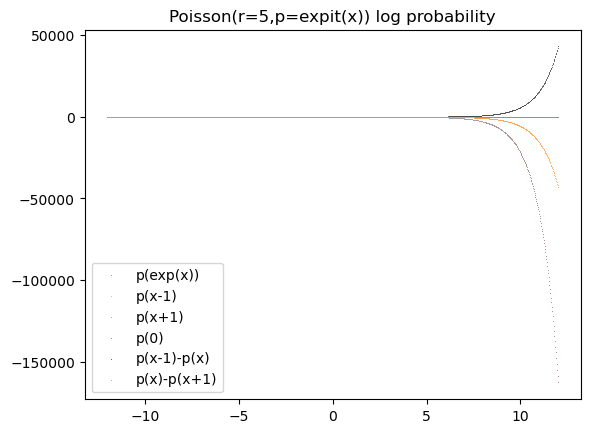

In [51]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-12., 12.,1000).unsqueeze(0)
log_probs=dist.Poisson(rate=mus.exp(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5,c='grey',label='p(x)-p(x+1)')
plt.title('Poisson(r=5,p=expit(x)) log probability')

Text(0.5, 1.0, 'NegativeBinomial(r=5,p=expit(x)) log probability')

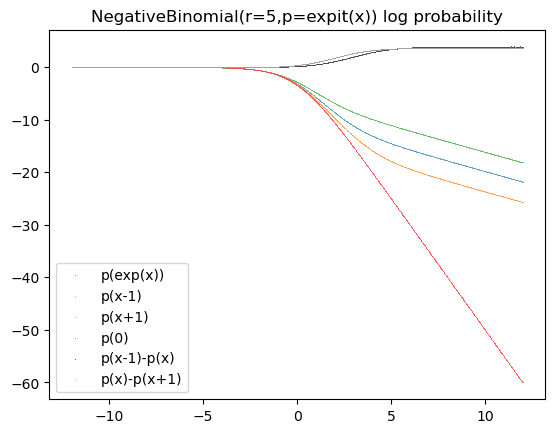

In [52]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-12., 12.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(logits=mus,total_count=total_counts,validate_args=False).log_prob(torch.cat([mus-total_counts.log(),mus-1-total_counts.log(),mus+1-total_counts.log(),mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5,c='grey',label='p(x)-p(x+1)')
plt.title('NegativeBinomial(r=5,p=expit(x)) log probability')

Text(0.5, 1.0, 'LogNormal(r=5,p=expit(x)) log probability')

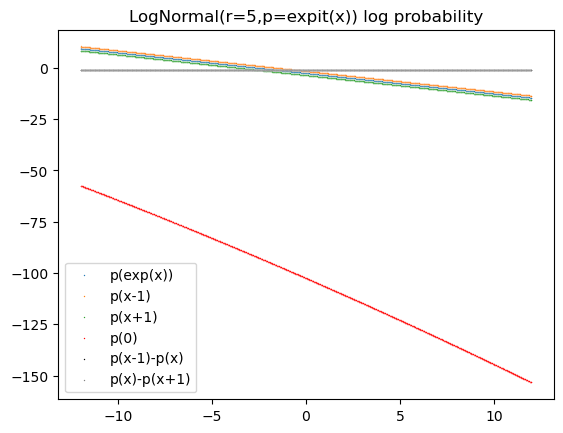

In [53]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-12., 12.,1000).unsqueeze(0)
log_probs=dist.LogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1.0,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=1.0,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=1.0,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=1.0,c='grey',label='p(x)-p(x+1)')
plt.title('LogNormal(r=5,p=expit(x)) log probability')

Text(0.5, 1.0, 'DiscreteWeibull(mu,sigma) log probability')

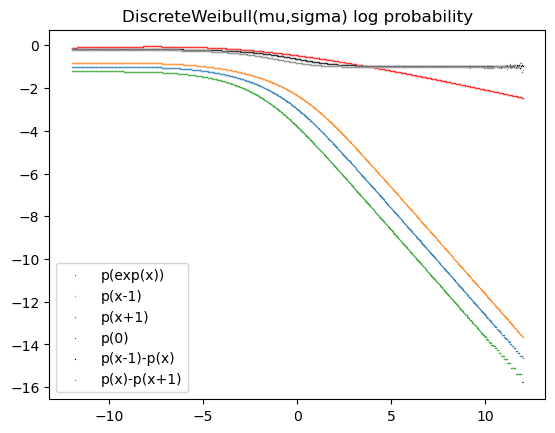

In [54]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-12., 12.,1000).unsqueeze(0)
log_probs=DiscreteWeibull(mu=mus,sigma=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1.0,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=1.0,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=1.0,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=1.0,c='grey',label='p(x)-p(x+1)')
plt.title('DiscreteWeibull(mu,sigma) log probability')

<Axes: >

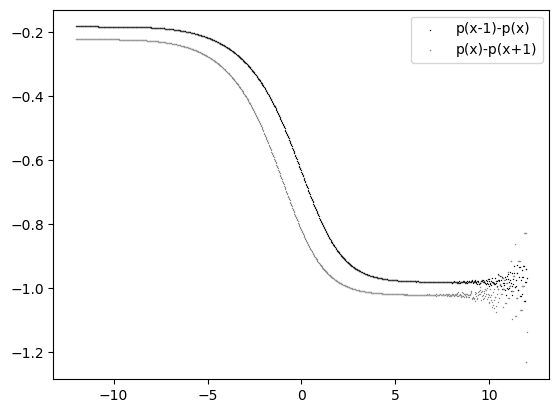

In [55]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=1.0,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=1.0,c='grey',label='p(x)-p(x+1)')

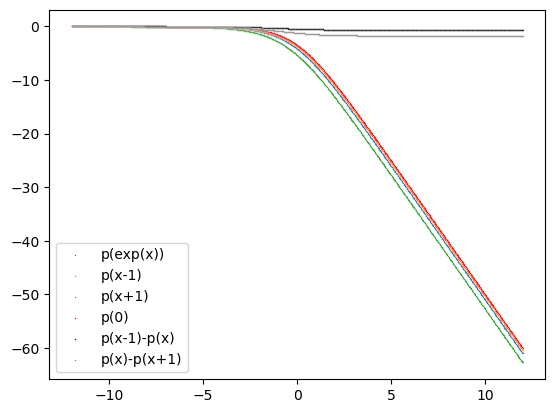

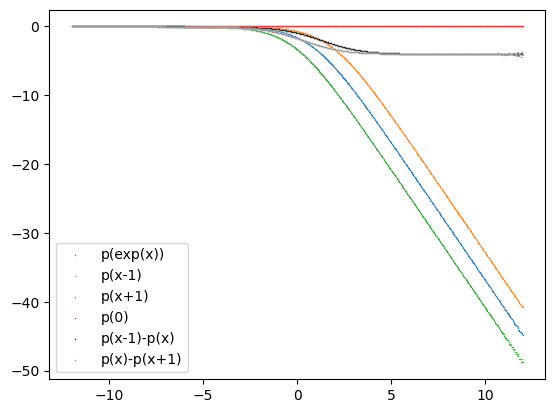

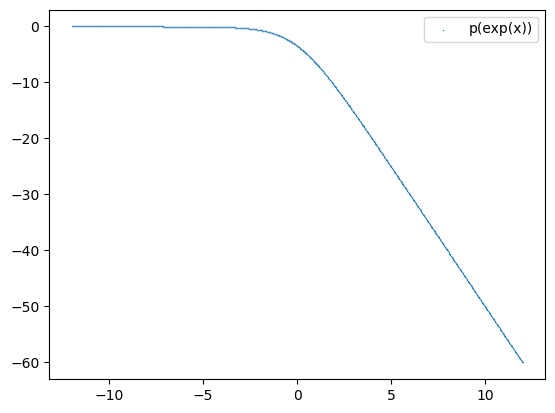

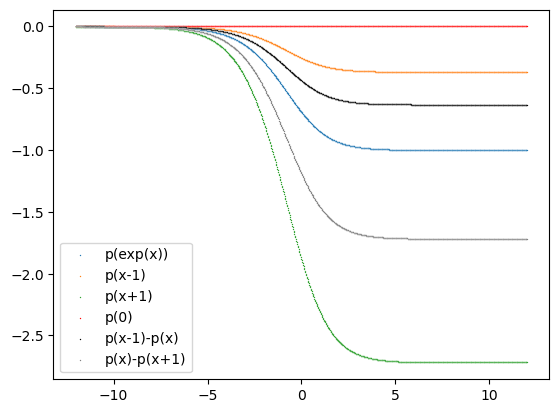

In [60]:
value = torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp()
logits = mus
total_counts=5*torch.ones(1)

log_unnormalized_prob = total_counts * torch.nn.functional.logsigmoid(
    -logits
) + value * torch.nn.functional.logsigmoid(logits)

log_normalization = (
    -torch.lgamma(total_counts + value)
    + torch.lgamma(1.0 + value)
    + torch.lgamma(total_counts)
)

neg_logits = total_counts * torch.nn.functional.logsigmoid(
    -logits
)

value_logits = value * torch.nn.functional.logsigmoid(logits)


seaborn.scatterplot(x=mus.numpy().flatten(),y=log_unnormalized_prob[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_unnormalized_prob[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_unnormalized_prob[2].numpy().flatten(),s=1.0,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_unnormalized_prob[3].numpy().flatten(),s=1.0,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_unnormalized_prob[0]-log_unnormalized_prob[1]).numpy().flatten(),s=1.0,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_unnormalized_prob[2]-log_unnormalized_prob[0]).numpy().flatten(),s=1.0,c='grey',label='p(x)-p(x+1)')
plt.show()
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_normalization[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_normalization[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_normalization[2].numpy().flatten(),s=1.0,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_normalization[3].numpy().flatten(),s=1.0,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_normalization[0]-log_normalization[1]).numpy().flatten(),s=1.0,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_normalization[2]-log_normalization[0]).numpy().flatten(),s=1.0,c='grey',label='p(x)-p(x+1)')
plt.show()
seaborn.scatterplot(x=mus.numpy().flatten(),y=neg_logits[0].numpy().flatten(),s=1.0,label='p(exp(x))')
plt.show()
seaborn.scatterplot(x=mus.numpy().flatten(),y=value_logits[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=value_logits[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=value_logits[2].numpy().flatten(),s=1.0,label='p(x+1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=value_logits[3].numpy().flatten(),s=1.0,c='red',label='p(0)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(value_logits[0]-value_logits[1]).numpy().flatten(),s=1.0,c='black',label='p(x-1)-p(x)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=(value_logits[2]-value_logits[0]).numpy().flatten(),s=1.0,c='grey',label='p(x)-p(x+1)')
plt.show()

# def log_prob(value,logits,total_counts):
#     if self._validate_args:
#         self._validate_sample(value)

#     log_unnormalized_prob = total_counts * torch.nn.functional.logsigmoid(
#         -logits
#     ) + value * F.logsigmoid(logits)

#     log_normalization = (
#         -torch.lgamma(total_counts + value)
#         + torch.lgamma(1.0 + value)
#         + torch.lgamma(total_counts)
#     )
#     # The case total_counts == 0 and value == 0 has probability 1 but
#     # lgamma(0) is infinite. Handle this case separately using a function
#     # that does not modify tensors in place to allow Jit compilation.
#     log_normalization = log_normalization.masked_fill(
#         total_counts + value == 0.0, 0.0
#     )

#     return log_unnormalized_prob - log_normalization

<Axes: >

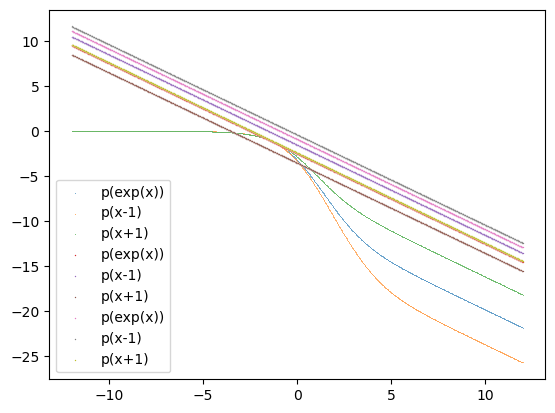

In [80]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-12., 12.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(logits=mus,total_count=total_counts,validate_args=False).log_prob(torch.cat([mus-total_counts.log(),mus-1-total_counts.log(),mus+1-total_counts.log(),mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5,label='p(x+1)')
log_probs=dist.LogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1.0,label='p(x+1)')
log_probs=dist.LogNormal(loc=mus,scale=0.2*total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=1.0,label='p(exp(x))')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=1.0,label='p(x-1)')
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=1.0,label='p(x+1)')




In [29]:
import numpy as np  # Ensure numpy is imported at the top

class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            transform_matrix = pyro.sample('transform_matrix_sample', dist.Laplace(torch.zeros(self.n_latent, self.n_var, device=device),100.*torch.ones(self.n_latent, self.n_var, device=device)).to_event(2))
            intercept = pyro.sample('intercept_sample', dist.Laplace(torch.zeros(self.n_components, self.n_var, device=device),100.*torch.ones(self.n_components, self.n_var, device=device)).to_event(2))
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', 4*torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                sigma = pyro.param('sigma', torch.zeros(self.n_var, device=device))
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device)), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]
                # out_mu = torch.nn.functional.log_softmax(out_mu,dim=-1)
                if data is not None:
                    out_mu = out_mu + l.log()
                    recon = pyro.sample('obs', DiscreteWeibull(mu=out_mu, sigma=sigma.exp(),validate_args=False).to_event(1), obs=data)
                    

    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            transform_matrix = pyro.param('transform_matrix', 0.01 * torch.randn(self.n_latent, self.n_var, device=device))
            intercept = pyro.param('intercept',  0.01*torch.randn(self.n_components, self.n_var, device=device))
            transform_matrix = pyro.sample('transform_matrix_sample', dist.Delta(transform_matrix).to_event(2))
            intercept = pyro.sample('intercept_sample', dist.Delta(intercept).to_event(2))
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent)), infer={"enumerate": "parallel"})



<Axes: >

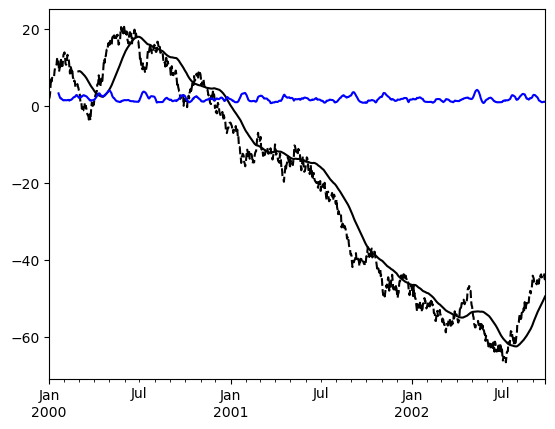

In [12]:
# some sample data
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000)).cumsum()

#plot the time series
ts.plot(style='k--')

# calculate a 60 day rolling mean and plot
ts.rolling(window=60,).mean().plot(style='k')

# add the 20 day rolling standard deviation:
ts.rolling(window=20).std().plot(style='b')


In [13]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 12*torch.rand(n_var)-6.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 8 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)

In [14]:
(data>0).sum(0)

tensor([ 1083,   316, 10269, 25068, 37205,  1275,  1483,   609, 11753, 14914,
         1434,     8,  2399,  2601,    87,   939,  3136,     6,  9047, 14071,
          932,   399,  7476, 11763,  1731,  1173, 11996,   246,  5571,    91,
          170,  3526,  3187, 24268,  6368,   207, 28629,  5756, 20086,   535,
        18752,    88, 29386,  4271,   123,   206,  6913,   501, 37376, 10669,
        31168, 45166,   114,  4967, 23152, 14676, 40246,   711, 12050, 11822,
        21906,   158, 23662,  7496,  6900, 32225,     3, 19186,  7390, 14517,
        23450,   211,     4,  1589, 23331,   530,     3, 34420, 25372, 25357,
         2594,  5308, 38170, 39359,  3488,  5349, 22623,  1462, 20527, 10241,
         4664, 19110,  5862,   181,    54, 23303,   102,   724, 47827,   567,
        16745, 33750,  5240, 16205, 21133,    16,   498, 25131,  8662,    12,
          305, 27350,   996,   118, 24689,  8172,  1896,  5535, 25595, 10071,
        36423,   414, 24924,    46, 11134, 18464,  7429, 23879, 

Text(0.5, 1.0, 'distribution of count values')

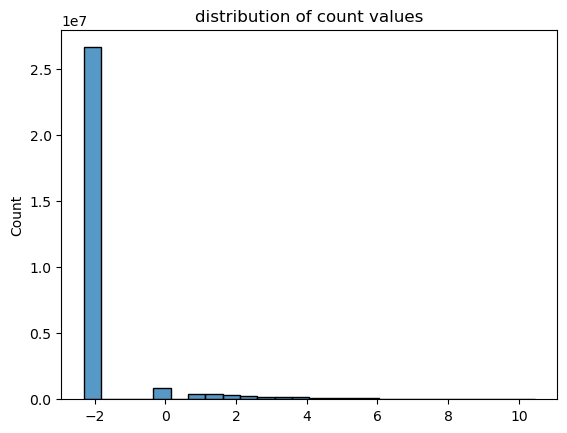

In [15]:
seaborn.histplot(np.log(data.flatten()+0.1))
plt.title('distribution of count values')

Text(0.5, 1.0, 'distribution of library sizes')

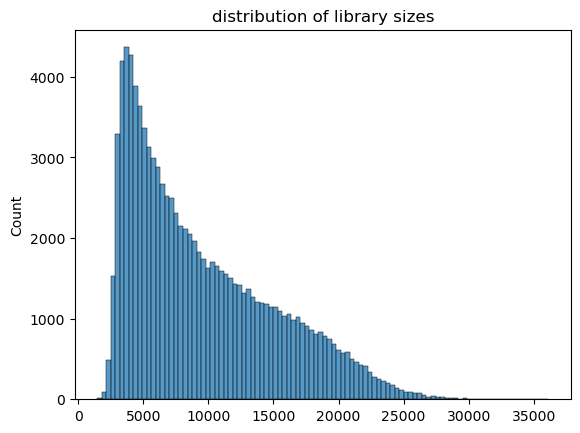

In [16]:

seaborn.histplot(data.sum(1).flatten(),bins=100)
plt.title('distribution of library sizes')

In [17]:
adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [30]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)

# SVI setup
adam_params = {"lr": 0.005}
optimizer = Adam(adam_params)

hide_all=[name for name in pyro.get_param_store() if not re.search('discov_di|intercept',name)]
svi = SVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 20
losses = []

In [31]:
for i in range(num_iterations):
    loss = 0
    for j in tqdm.tqdm(range(0, n_datapoints, batch_size)):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

100%|██████████| 3125/3125 [01:28<00:00, 35.34it/s]


Iteration 0 : Loss 5.979850769042969


100%|██████████| 3125/3125 [01:27<00:00, 35.63it/s]


Iteration 1 : Loss 5.943808078765869


100%|██████████| 3125/3125 [01:27<00:00, 35.90it/s]


...

Iteration 17 : Loss 5.972626209259033


100%|██████████| 3125/3125 [01:27<00:00, 35.83it/s]


Iteration 18 : Loss 5.92165994644165


100%|██████████| 3125/3125 [01:27<00:00, 35.67it/s]

Iteration 19 : Loss 5.91506290435791
Training complete.


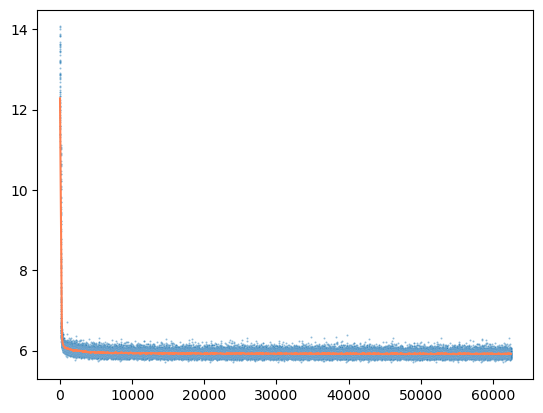

In [32]:
antipode.plotting.plot_loss(losses)

In [33]:
toy_model.eval()
latents=[]
clusters=[]
for j in range(0, n_datapoints, batch_size):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [34]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [35]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


INFO     Using cuda:0 for `pymde.preserve_neighbors`.                                                              


/home/matthew.schmitz/Matthew/utils/miniforge3/envs/antipode/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:191: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.11 /home/matthew.schmitz/Matthew/utils/miniforge3/e ...


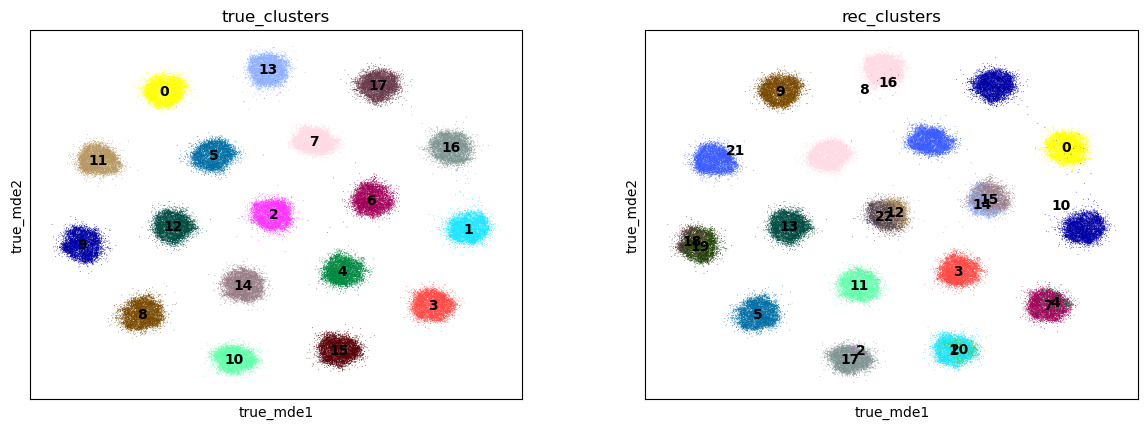

In [36]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


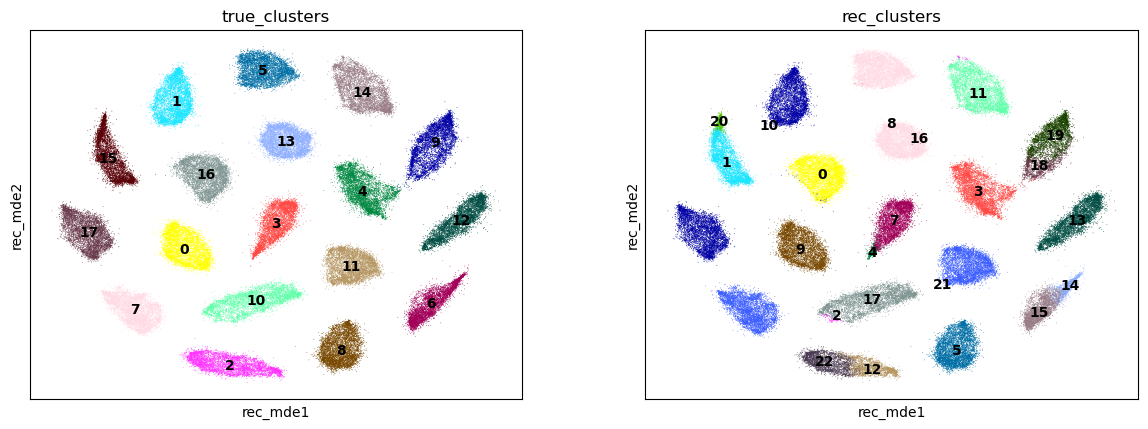

In [37]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

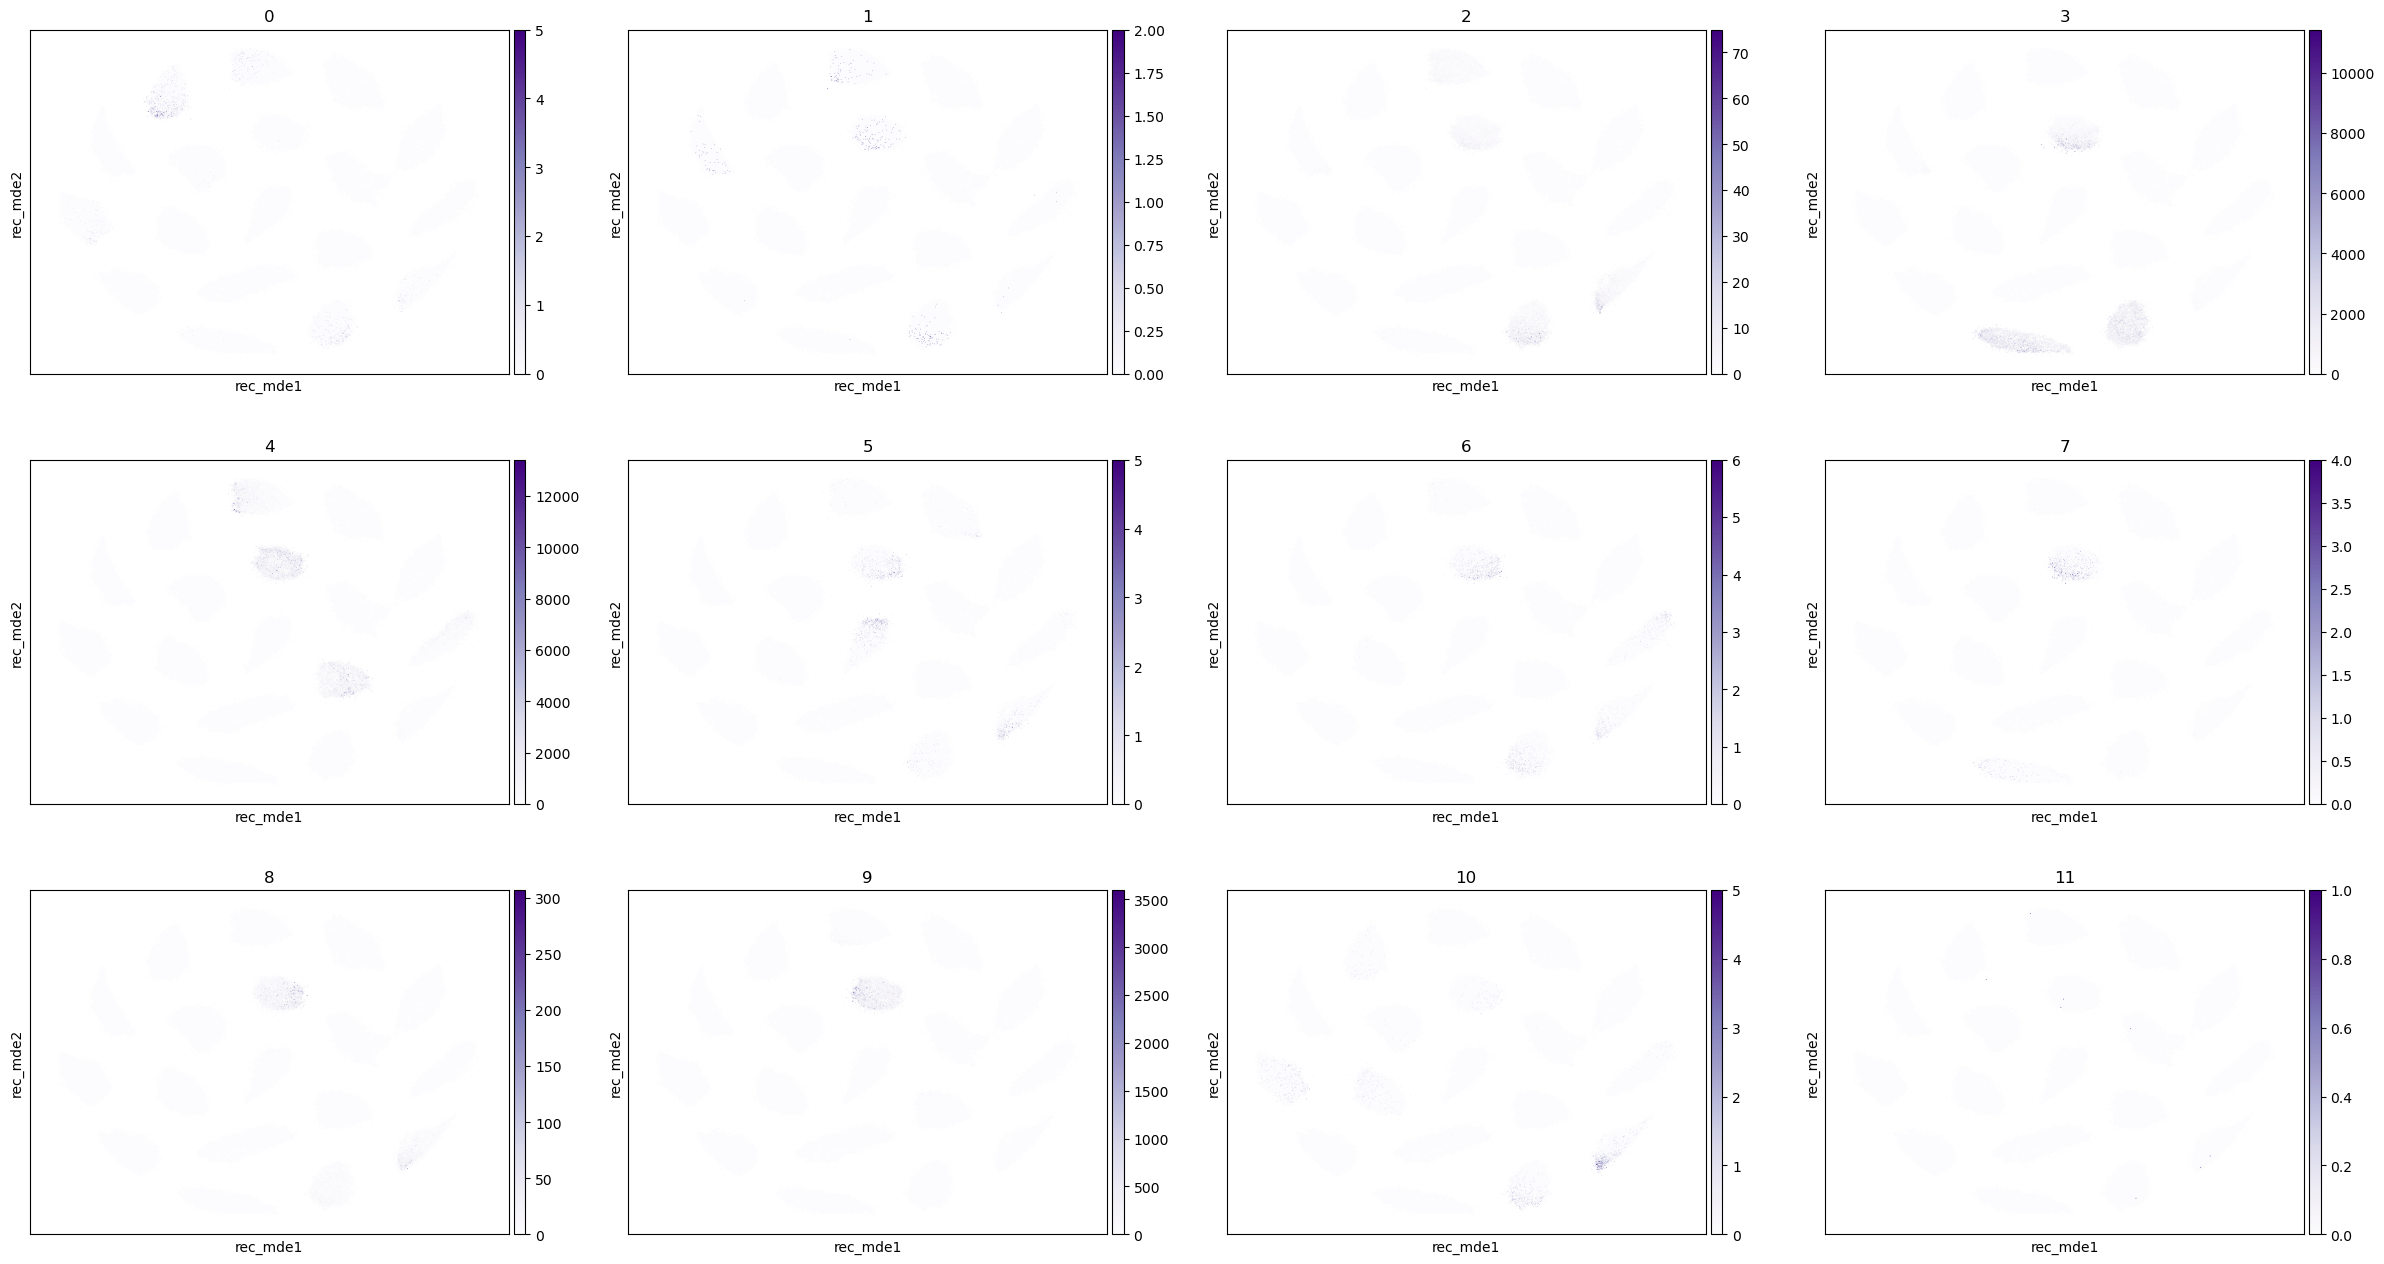

In [38]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=adata.var.index[0:12],
    cmap='Purples',
    legend_loc='on data'
)

In [39]:
out_locs = pyro.param('locs').detach().cpu().numpy()
out_transform_matrix = pyro.param('transform_matrix').detach().cpu().numpy()
out_intercept = pyro.param('intercept').detach().cpu().numpy()

# Compute the learned cluster means
learned_means = (out_locs @ out_transform_matrix + out_intercept)#torch.nn.functional.log_softmax(torch.tensor(out_locs @ out_transform_matrix + out_intercept),dim=-1).numpy()
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.5)

100%|██████████| 22/22 [00:00<00:00, 106.12it/s]


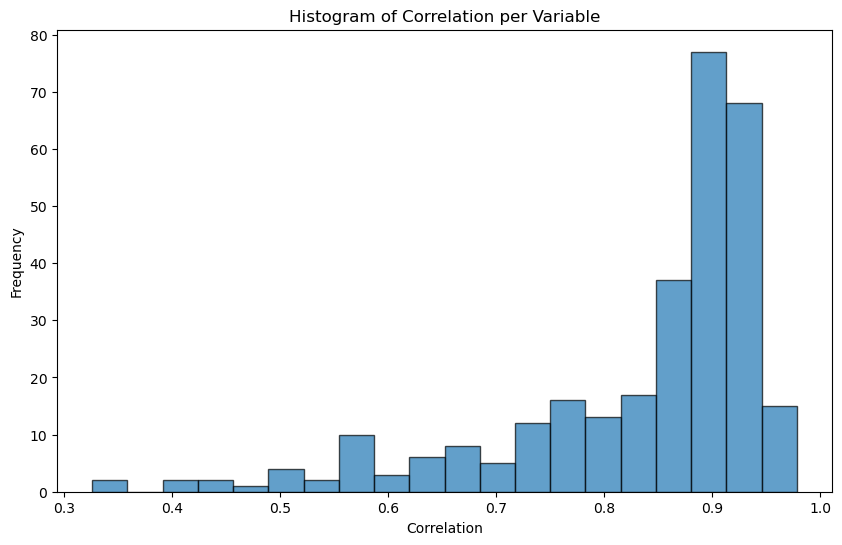

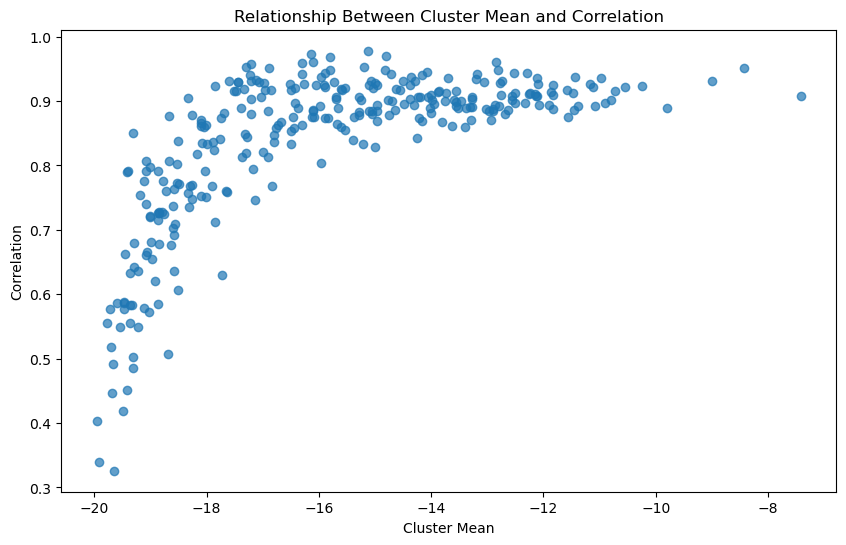

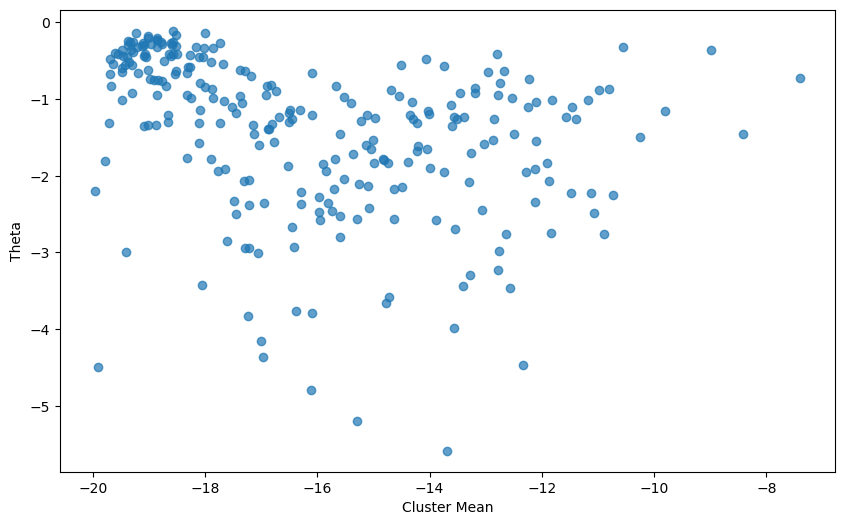

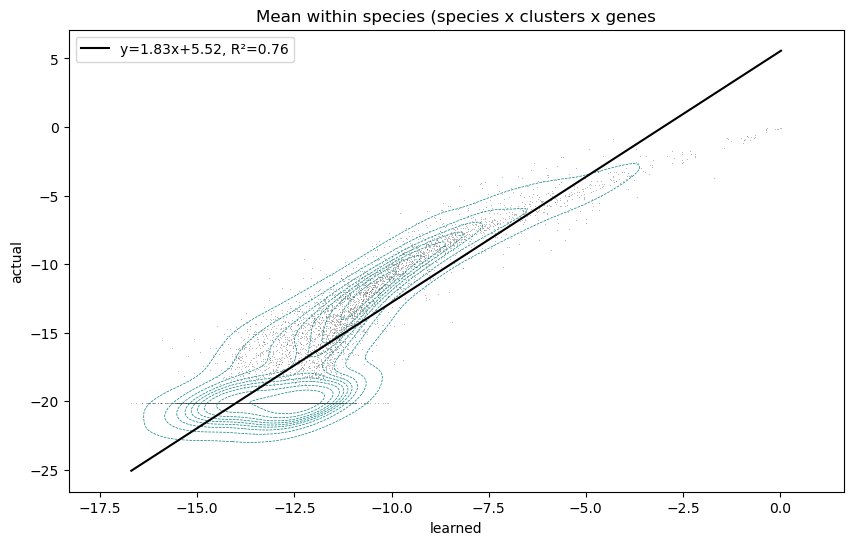

In [40]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('sigma').log().cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
x=learned_means.flatten()
y=actual_means.flatten()
seaborn.scatterplot(x=x,y=actual_means.flatten(),s=0.2,color='black')
seaborn.kdeplot(x=learned_means.flatten(),y=y,linestyles='--',color='teal', linewidths=0.5)
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='black', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')
# Add legend
plt.legend()
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [41]:
x=actual_means.flatten()
y=learned_means.flatten()
y=y - x

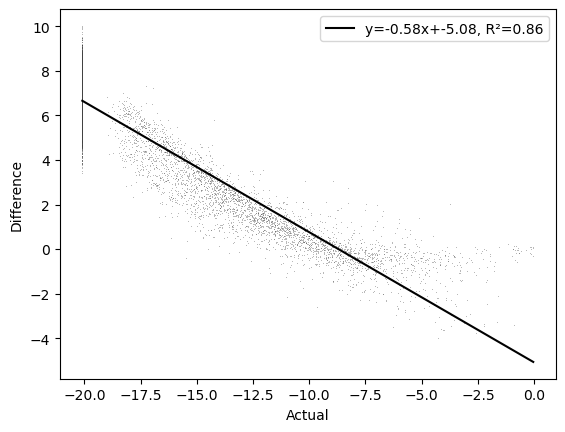

In [42]:
seaborn.scatterplot(x=x,y=y,s=0.2,color='black')
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)
# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='black', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.xlabel('Actual')
plt.ylabel('Difference')
plt.legend()

In [43]:
x=learned_means
y=actual_means

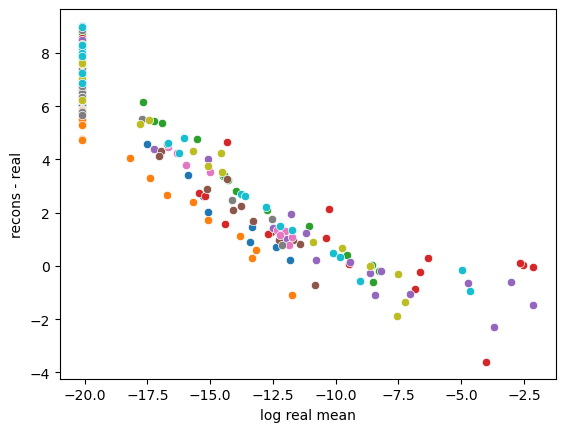

In [44]:
for g in range(10):
    seaborn.scatterplot(y=x[:,g].flatten()-y[:,g].flatten(),x=y[:,g].flatten())
plt.xlabel('log real mean')
plt.ylabel('recons - real')
plt.show()